In [1]:
dir = r'/home/zyyk78/HDD/zyyk78/Stage3/A05' 
log_dir=r'/home/zyyk78/HDD/zyyk78/llom_log'

In [2]:
#初始化
import os
import fixing
from ParseEvent import ParseEvent
import pickle
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


def find_evt_files_without_pkl(dir=str):
    evt_files_without_pkl = []
    for root, dirs, files in os.walk(dir):
        for file in files:
            if file.endswith('.evt'):
                pkl_file_name = os.path.splitext(file)[0] + '.pkl'
                if pkl_file_name not in files:
                    evt_file_path = os.path.join(root, file)
                    evt_files_without_pkl.append(evt_file_path)
    
    return evt_files_without_pkl

Paths = find_evt_files_without_pkl(dir)
count=0
Event=None
if(len(Paths)==0):
    print('No evt to be processed!\n')
else:
    print('Find '+str(len(Paths))+' File(s)!')

delta1=25000
delta2=10000
df = pd.DataFrame()
if os.path.exists(os.path.join(dir,"README.xlsx")):
    df = pd.read_excel(os.path.join(dir,"README.xlsx"),sheet_name='Sheet1',header=None) .iloc[2:,:]
    print('Find CSV data!')


Find 10 File(s)!
Find CSV data!


In [3]:
# You can view and edit data here
if (count < len(Paths)):
    print('Processing file '+str(count+1)+'/'+str(len(Paths))+': '+Paths[count])
    Event=ParseEvent(Paths[count])
    target_date = os.path.basename(Paths[count]).split('_')[0]
    log_file = os.path.join(log_dir, f"log{target_date}.txt")

    matched_row=pd.DataFrame
    if not df.empty:
        matched_row = df[df[0]==int(target_date)] 
        print('Find matched row in CSV data!')
        print(f'Target Tring mode: {matched_row.iloc[0,2]}')
    Event,log_Event=fixing.fixing(Event,26000,39000,log_file,matched_row)
else:
    print('All Finished!\n')

Processing file 1/10: /home/zyyk78/HDD/zyyk78/Stage3/A05/20250313_00.evt
Find matched row in CSV data!
Target Tring mode: P
Log file /home/zyyk78/HDD/zyyk78/llom_log/log20250313.txt found. Event is matched to 1, time difference is 0 seconds.
No SlnR Event! Fixing 
No Mod info!
Fixing with log! 
Matching SlnL
396 events in hw, 399 events in sw, 396 matched!
Fit data: a=1.00, b=2.20(s), r^2=1.00
Matching ROmL
42 events in hw, 42 events in sw, 42 matched!
Fit data: a=1.00, b=2.18(s), r^2=1.00
ROmR Event too short! Removed!
2 Events matched! a=1.00±0.00, b=2.19±0.01(s)
No SlnR Event! Fixing 


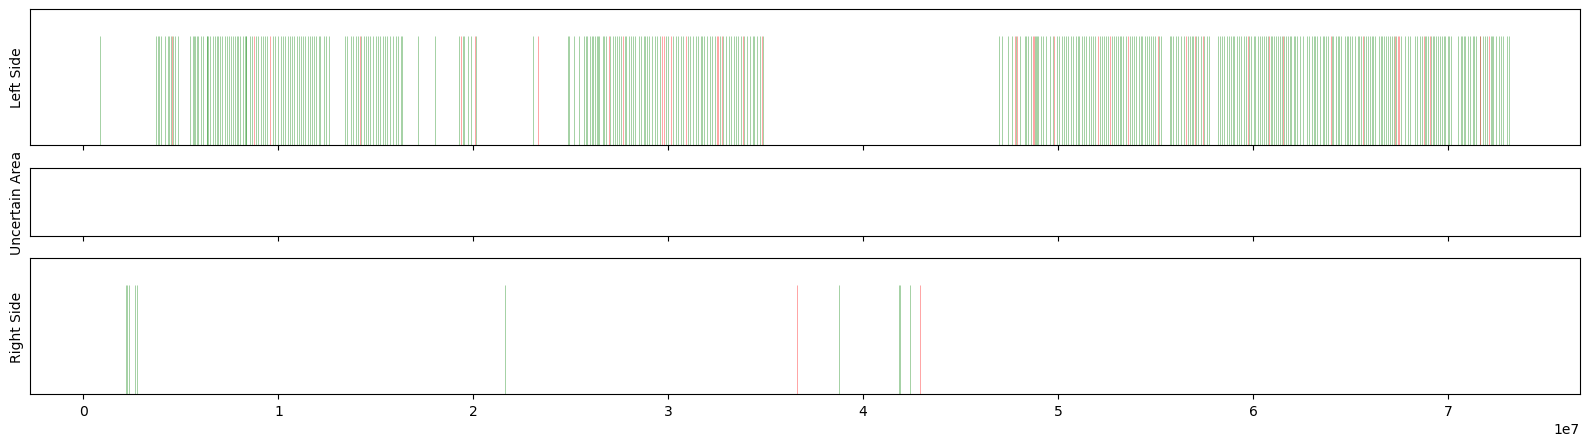

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax1_5, ax2) = plt.subplots(3, 1, figsize=(20, 5), 
                                   gridspec_kw={'height_ratios': [2 , 1 , 2]},sharex=True,)
sns.rugplot(Event['SlnL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['SlnR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['ROmL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ROmR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ModL']['Time_S'] , ax=ax1, height=1, linewidth=1.5, color='blue')
sns.rugplot(Event['ModR']['Time_S'] , ax=ax2, height=1, linewidth=1.5, color='blue')

if 'Blackhole' in Event:
    for i in range(len(Event['Blackhole']['Time_S'])):
        ax1_5.fill_betweenx(y=[-0.5, 0.5], x1 = Event['Blackhole']['Time_S'][i], x2=Event['Blackhole']['Time_E'][i],color='red')
ax1.set_yticks([])
ax1.set_ylabel('Left Side')
ax2.set_yticks([])
ax2.set_ylabel('Right Side')
ax1_5.set_yticks([])
ax1_5.set_ylabel('Uncertain Area')
plt.show()

In [11]:
if (Event != None):
    pkl_path=os.path.splitext(Paths[count])[0] + '.pkl'
    with open(pkl_path,"wb") as pkl_f:
        pickle.dump(Event,pkl_f)
        Event=None
    print('File Saved to: '+pkl_path)
else:
    print('Event = Null!! Pkl won\'t be saved!')
count += 1

Event = Null!! Pkl won't be saved!


Process All File Automatically！

In [5]:
while (count < len(Paths)):
    print('Processing file '+str(count+1)+'/'+str(len(Paths))+': '+Paths[count])
    Event=ParseEvent(Paths[count])
    target_date = os.path.basename(Paths[count]).split('_')[0]
    log_file = os.path.join(log_dir, f"log{target_date}.txt")
    matched_row=pd.DataFrame
    if not df.empty:
        matched_row = df[df[0]==int(target_date)] 
        print('Find matched row in CSV data!')
        print(f'Target Tring mode: {matched_row.iloc[0,2]}')
    Event,log_Event=fixing.fixing(Event,26000,39000,log_file,matched_row)
    if (Event != None):
        pkl_path=os.path.splitext(Paths[count])[0] + '.pkl'
        with open(pkl_path,"wb") as pkl_f:
            pickle.dump(Event,pkl_f)
            Event=None
        print('File Saved to: '+pkl_path)
    else:
        print('Event = Null!! Pkl won\'t be saved!')
    count += 1
print('All Finished!\n')
    

Processing file 1/10: /home/zyyk78/HDD/zyyk78/Stage3/A05/20250313_00.evt
Find matched row in CSV data!
Target Tring mode: P
Log file /home/zyyk78/HDD/zyyk78/llom_log/log20250313.txt found. Event is matched to 1, time difference is 0 seconds.
No SlnR Event! Fixing 
No Mod info!
Fixing with log! 
Matching SlnL
396 events in hw, 399 events in sw, 396 matched!
Fit data: a=1.00, b=2.20(s), r^2=1.00
Matching ROmL
42 events in hw, 42 events in sw, 42 matched!
Fit data: a=1.00, b=2.18(s), r^2=1.00
ROmR Event too short! Removed!
2 Events matched! a=1.00±0.00, b=2.19±0.01(s)
No SlnR Event! Fixing 
File Saved to: /home/zyyk78/HDD/zyyk78/Stage3/A05/20250313_00.pkl
Processing file 2/10: /home/zyyk78/HDD/zyyk78/Stage3/A05/20250321_00.evt
Find matched row in CSV data!
Target Tring mode: T
Log file /home/zyyk78/HDD/zyyk78/llom_log/log20250321.txt found. Event is matched to 1, time difference is 0 seconds.
No SlnR Event! Fixing 
No ModR Event! Fixing 
Fixing with log! 
Matching SlnL
197 events in hw, 1

In [ ]:
#如果需要修正,可以从这里估算参数 i j 分别对应delta1和delta2  反正 就是 取那一组没问题的数据 相互验证
import matplotlib.pyplot as plt
seq={
    'i':[],
    'j':[],
    'delta2':[],
    'delta_2':[] 
}
seq_=[]
for i in range (20,40):
    for j in range (20,40):
        recog  = fixing.recog_trials(Event['LickL']['Time_S'],delta=i*1000)

        delta1 = fixing.find_not_matched(recog,Event['ROmL']['Time_S'],delta=j*1000)
        delta2 = fixing.find_not_matched(delta1,Event['SlnL']['Time_S'],delta=j*1000)  #多的

        delta_1 = fixing.find_not_matched(Event['ROmL']['Time_S'],recog,delta=j*1000)
        delta_2 = fixing.find_not_matched(delta_1,Event['SlnL']['Time_S'],delta=j*1000)   #少的
        seq['i'].append(i)
        seq['j'].append(j)
        seq['delta2'].append(len(delta2))
        seq['delta_2'].append(len(delta_2))
        seq_.append([i,j,len(delta2)+len(delta_2)])  #按照总误差排序
plt.scatter(seq['delta2'],seq['delta_2'])
plt.xlabel('Extra')
plt.ylabel('Missing')
seq_.sort(key=lambda x:abs(x[0]-x[1]))
seq_.sort(key=lambda x:x[2])  
print(seq_[0][0]*1000,seq_[0][1]*1000)